# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


This dataset is mental_health_burnout_tech_2026.csv, a survey of 100,000 tech-industry employees in 2026 measuring burnout and the workplace and lifestyle factors that drive it. The full file contains 36 columns covering demographics, job characteristics, work habits, lifestyle behaviors, and several mental-health screening scores. 

The target is burnout_score — a continuous measure ranging from 0.0 to 10.0, where 0 means no burnout and 10 means severe burnout.

In [2]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

sns.set_palette('bright')
warnings.filterwarnings("ignore")

df_full = pd.read_csv('mental_health_burnout_tech_2026.csv')

# Keep only the 5 features + target (plus burnout_level for context)
features_numeric = ['work_hours_per_week', 'sleep_hours_per_night', 'manager_support_score']
features_categorical = ['work_mode', 'seniority_level']
target = 'burnout_score'

df = df_full[features_numeric + features_categorical + [target, 'burnout_level']].copy()
df.head()

,work_hours_per_week,sleep_hours_per_night,manager_support_score,work_mode,seniority_level,burnout_score,burnout_level
0,55,6.3,6.0,Remote,Lead,10.0,Severe
1,44,4.7,7.6,Hybrid,Manager,7.0,High
2,45,6.0,4.8,On-site,Lead,8.5,Severe
3,54,6.5,6.7,Remote,Lead,10.0,Severe
4,49,7.4,7.9,Hybrid,Junior,5.4,Moderate


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   work_hours_per_week    100000 non-null  int64  
 1   sleep_hours_per_night  100000 non-null  float64
 2   manager_support_score  100000 non-null  float64
 3   work_mode              100000 non-null  object 
 4   seniority_level        100000 non-null  object 
 5   burnout_score          100000 non-null  float64
 6   burnout_level          100000 non-null  object 
dtypes: float64(3), int64(1), object(3)
memory usage: 5.3+ MB


work_hours_per_week      0
sleep_hours_per_night    0
manager_support_score    0
work_mode                0
seniority_level          0
burnout_score            0
burnout_level            0
dtype: int64


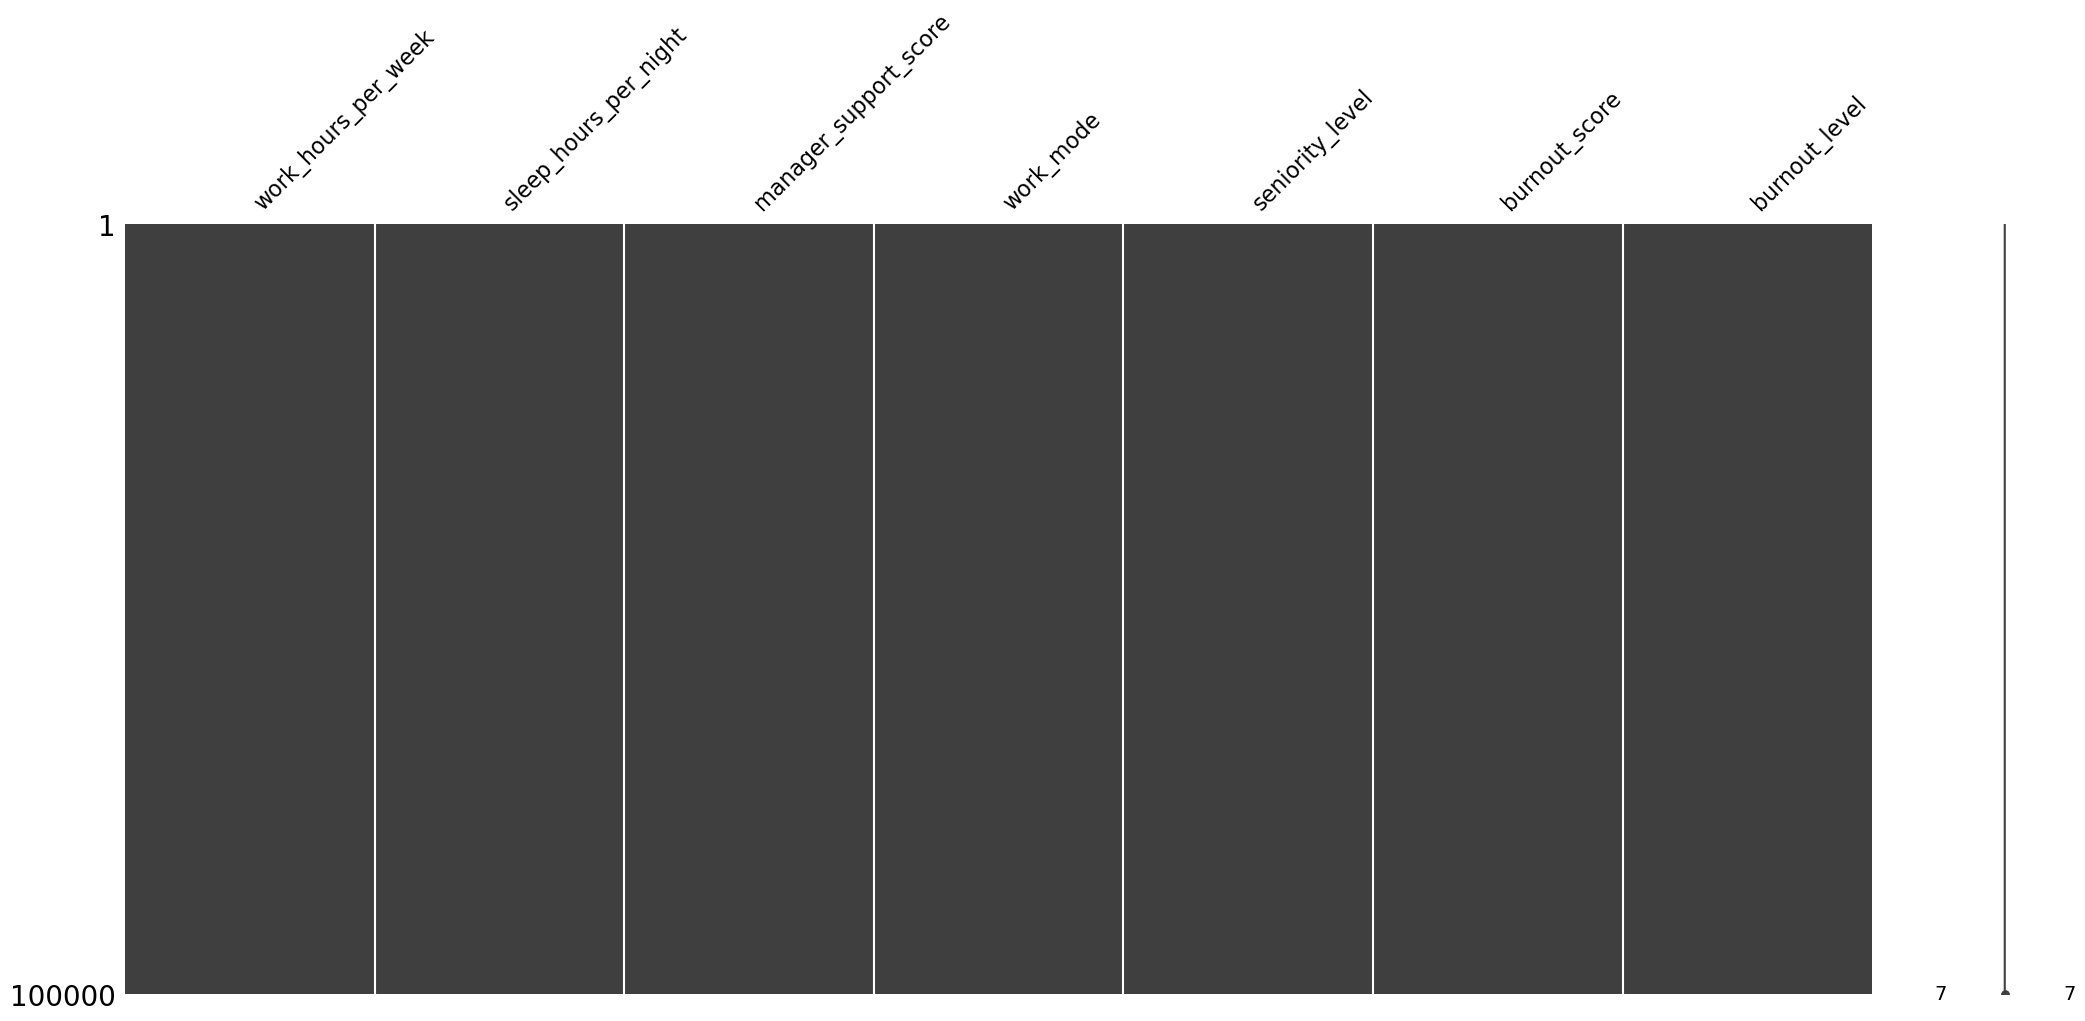

In [4]:
print(df.isnull().sum())
msno.matrix(df)
plt.show()

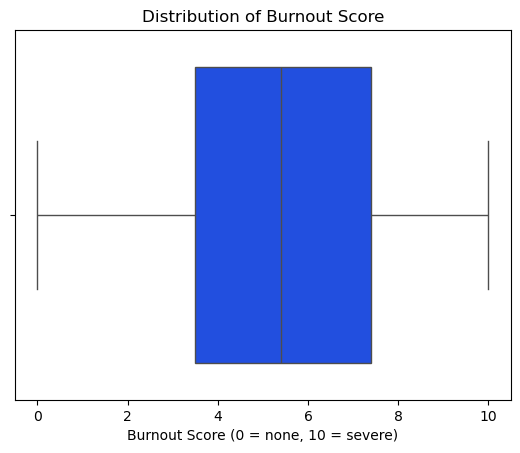

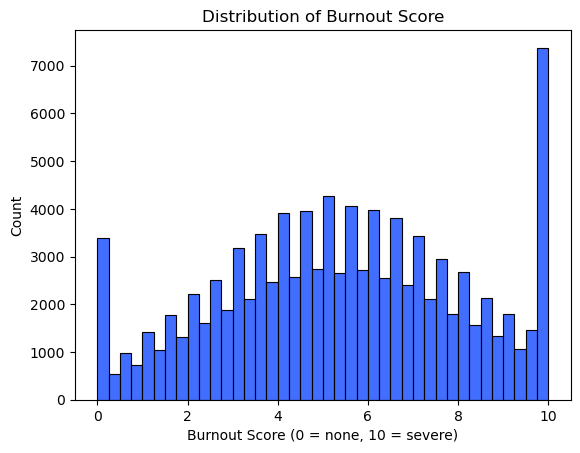

count    100000.000000
mean          5.401675
std           2.668425
min           0.000000
25%           3.500000
50%           5.400000
75%           7.400000
max          10.000000
Name: burnout_score, dtype: float64


In [5]:
sns.boxplot(data=df, x=target)
plt.title('Distribution of Burnout Score')
plt.xlabel('Burnout Score (0 = none, 10 = severe)')
plt.show()

sns.histplot(data=df, x=target, bins=40)
plt.title('Distribution of Burnout Score')
plt.xlabel('Burnout Score (0 = none, 10 = severe)')
plt.show()

print(df[target].describe())

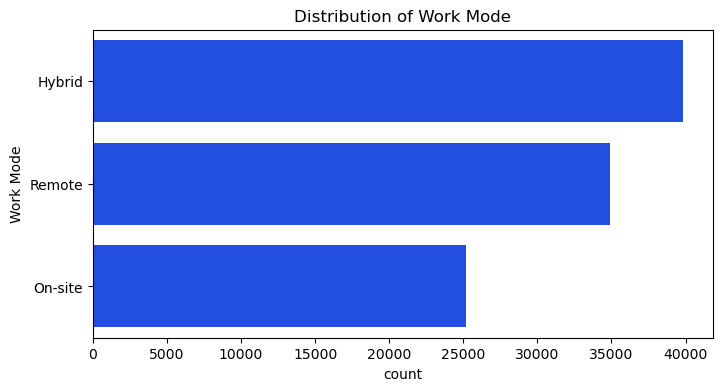

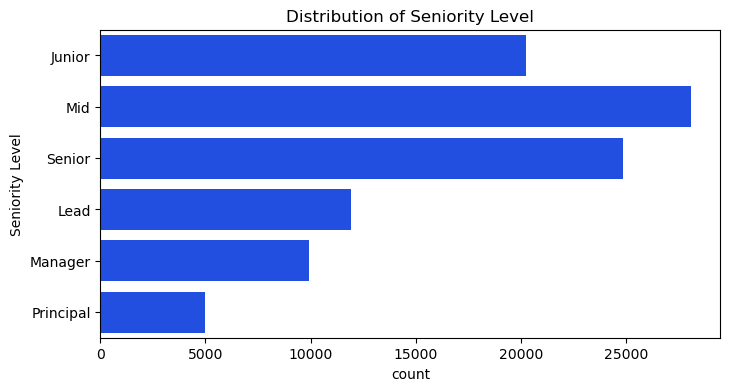

In [6]:
feature_titles = {
    'work_mode': 'Work Mode',
    'seniority_level': 'Seniority Level'
}
seniority_order = ['Junior', 'Mid', 'Senior', 'Lead', 'Manager', 'Principal']

for feature in features_categorical:
    plt.figure(figsize=(8, 4))
    if feature == 'seniority_level':
        sns.countplot(data=df, y=feature, order=seniority_order)
    else:
        sns.countplot(data=df, y=feature, order=df[feature].value_counts().index)
    plt.title(f"Distribution of {feature_titles[feature]}")
    plt.ylabel(feature_titles[feature])
    plt.show()

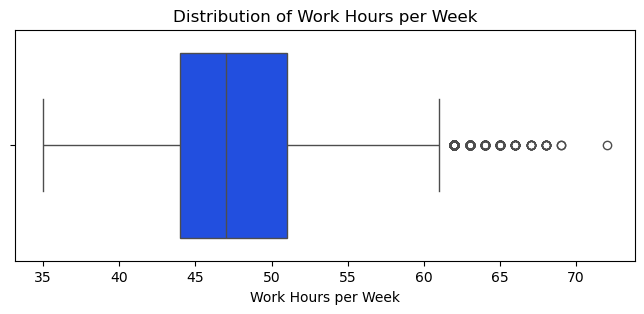

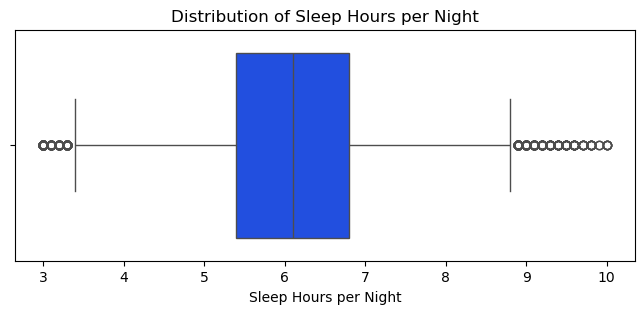

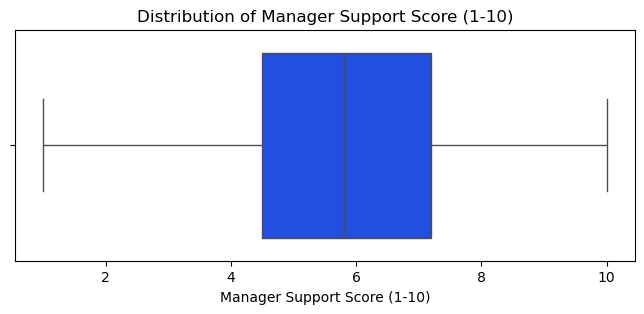

In [7]:
num_titles = {
    'work_hours_per_week': 'Work Hours per Week',
    'sleep_hours_per_night': 'Sleep Hours per Night',
    'manager_support_score': 'Manager Support Score (1-10)'
}

for feature in features_numeric:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=df, x=feature)
    plt.title(f"Distribution of {num_titles[feature]}")
    plt.xlabel(num_titles[feature])
    plt.show()

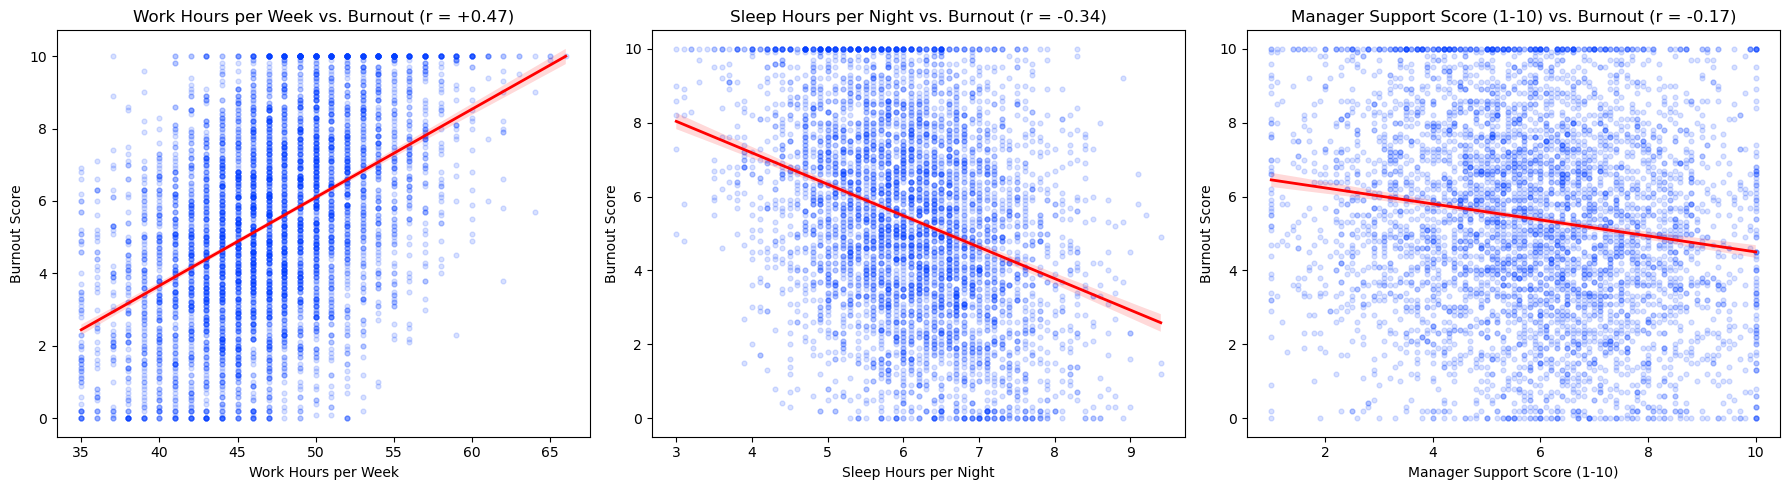

In [8]:
#sample so that the plots aren't just a solid wall
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feature in zip(axes, features_numeric):
    sns.regplot(data=sample, x=feature, y=target, ax=ax,
                scatter_kws={'alpha': 0.15, 's': 12},
                line_kws={'color': 'red', 'linewidth': 2})
    r = df[[feature, target]].corr().iloc[0, 1]
    ax.set_title(f"{num_titles[feature]} vs. Burnout (r = {r:+.2f})")
    ax.set_xlabel(num_titles[feature])
    ax.set_ylabel('Burnout Score')
plt.tight_layout()
plt.show()

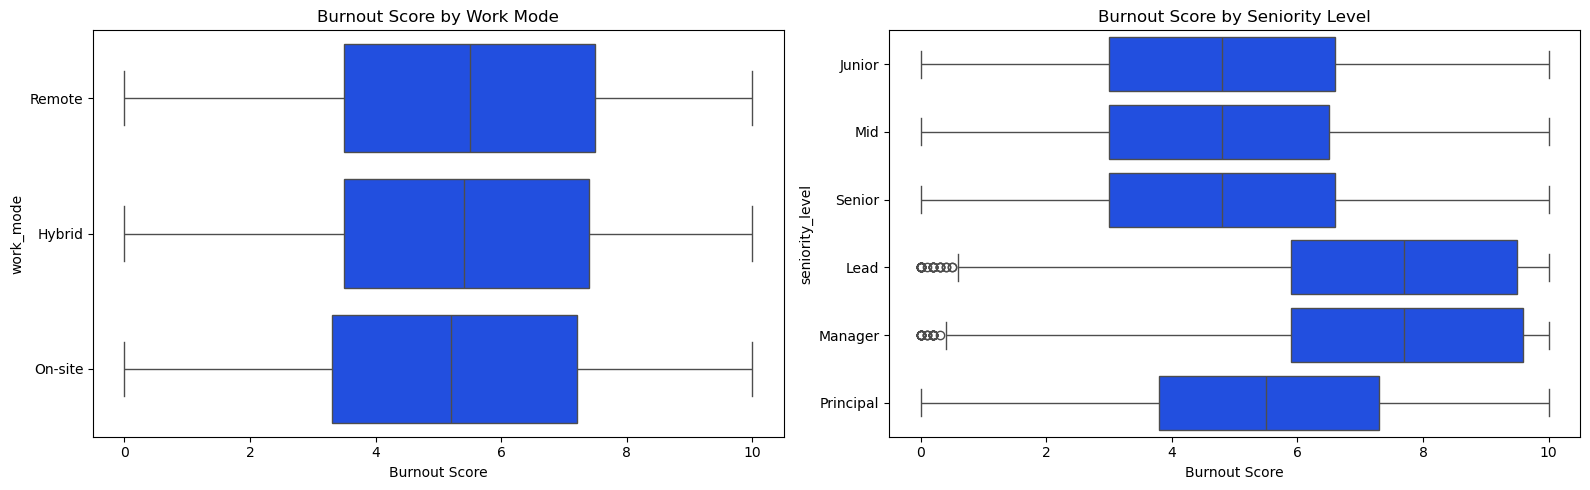

Median burnout score by work_mode:
work_mode
Remote     5.5
Hybrid     5.4
On-site    5.2
Name: burnout_score, dtype: float64

Median burnout score by seniority_level:
seniority_level
Junior       4.8
Mid          4.8
Senior       4.8
Lead         7.7
Manager      7.7
Principal    5.5
Name: burnout_score, dtype: float64


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df, x=target, y='work_mode', ax=axes[0],
            order=['Remote', 'Hybrid', 'On-site'])
axes[0].set_title('Burnout Score by Work Mode')
axes[0].set_xlabel('Burnout Score')

sns.boxplot(data=df, x=target, y='seniority_level', ax=axes[1],
            order=seniority_order)
axes[1].set_title('Burnout Score by Seniority Level')
axes[1].set_xlabel('Burnout Score')

plt.tight_layout()
plt.show()

print("Median burnout score by work_mode:")
print(df.groupby('work_mode')[target].median().sort_values(ascending=False))
print("\nMedian burnout score by seniority_level:")
print(df.groupby('seniority_level')[target].median().reindex(seniority_order))

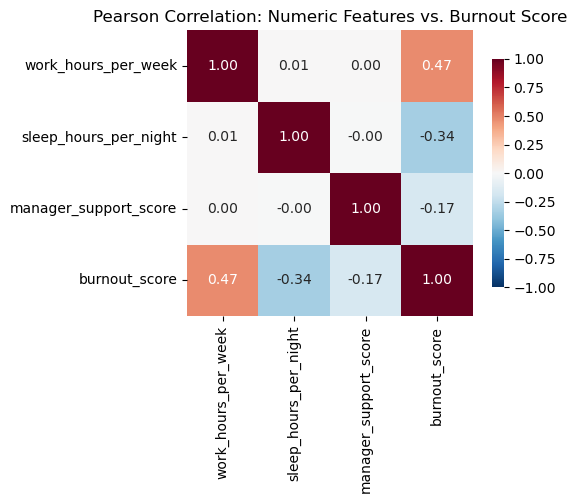

,work_hours_per_week,sleep_hours_per_night,manager_support_score,burnout_score
work_hours_per_week,1.000000,0.006383,0.000152,0.474050
sleep_hours_per_night,0.006383,1.000000,-0.002010,-0.338268
manager_support_score,0.000152,-0.002010,1.000000,-0.168501
burnout_score,0.474050,-0.338268,-0.168501,1.000000


In [10]:
corr = df[features_numeric + [target]].corr(method='pearson')

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title('Pearson Correlation: Numeric Features vs. Burnout Score')
plt.tight_layout()
plt.show()

corr

Hours worked per week was the strongest single predictor of burnout, with a correlation of about +0.47. The regplot showed a clean upward trend: every additional hour worked per week pushed the average burnout score noticeably higher.

Work mode showed almost identical burnout distributions for Remote, Hybrid, and On-site employees — all three group medians sat within roughly 0.2 points of each other on the 10-point scale.

Seniority level was similarly flat: Junior, Mid, Senior, Lead, Manager, and Principal employees all reported median burnout scores in the same narrow band.

Burnout in tech is driven by what you do, not who you are or where you sit. The variables that captured the signal were workload and lifestyle. hours worked, sleep, and the quality of your manager. while the structural variables that get the most attention in industry conversations (remote vs. office, junior vs. senior) were essentially noise.